# 01 - Mission Segments Overview

The eVTOL flight mission is divided into discrete segments. Each segment has defined velocities (horizontal and/or vertical) and a duration. This notebook walks through all segments, builds a timeline view, and visualizes the velocity and altitude profiles.

## Power Calculation Categories

Each segment uses a different approach to compute shaft power, depending on the flight regime. From the theory document (`docs/theory/evtol-sizing.md`), the segments fall into three categories:

| Category | Segments | Physics | Shaft Power Formula |
|---|---|---|---|
| **Hover-only** | Taxi, Hover Climb/Descend | No aerodynamic drag; thrust from momentum theory | $P = T \cdot v_i / \eta_{rotor}$ where $v_i = \sqrt{T/(2\rho A)}$ |
| **Wing-borne** | Procedures, Cruise | Full aero drag (induced + parasite); constant velocity | $P = D_{total} \cdot v_h / \eta_{rotor}$ |
| **Transition** | Trans. Climb/Descend, Accel Climb, Decel Descend | Combined hover-assist + aero drag; accelerating | $P = (P_{hover} + F_h \cdot v_h) / \eta_{rotor}$ |

The general form for all segments is:

$$P_{shaft,avg} = \frac{F_h \cdot v_h + F_v \cdot v_v}{\eta_{rotor}}$$

where $F_h$ and $F_v$ are horizontal and vertical force components derived from drag, weight, lift, and acceleration requirements.

In [9]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../../')))
from evtol.aircraft import Aircraft

aircraft = Aircraft('../Archer_Midnight.json')

## Primary Mission Segments

The primary mission has 11 segments that represent a complete vertiport-to-vertiport flight. The mission profile is adapted from [Uber Elevate's *UberAir Vehicle Requirements and Mission*](../../references/summary-mission-and-requirements.pdf).

1. **Depart Taxi** - Ground taxi to takeoff pad (hover-only, horizontal acceleration from rest)
2. **Hover Climb** - Vertical ascent from ground (hover-only, vertical acceleration; uses momentum theory: $T = m(g + a_v)$)
3. **Transition Climb** - Accelerate horizontally while climbing (transition: rotors provide lift supplement as wing generates increasing lift)
4. **Depart Procedures** - Procedure turns near departure (wing-borne, constant velocity)
5. **Accelerate Climb** - Climb to cruise altitude while accelerating (transition: horizontal and vertical forces)
6. **Cruise** - Level flight at cruise speed (wing-borne, constant velocity; uses cruise drag)
7. **Decelerate Descend** - Descend while decelerating
8. **Arrive Procedures** - Procedure turns near arrival (wing-borne, constant velocity)
9. **Transition Descend** - Decelerate horizontally while descending (transition: hover-assist)
10. **Hover Descend** - Vertical descent to ground (hover-only, decelerates to rest; $T = m(g + a_v)$)
11. **Arrive Taxi** - Ground taxi to gate

In [10]:
mission = aircraft.mission

# Primary segments: name, horizontal velocity, vertical velocity, duration
primary_segments = [
    ('Depart Taxi',         mission.depart_taxi_avg_h_m_p_s,    0.0,                              mission.depart_taxi_s),
    ('Hover Climb',         0.0,                                mission.hover_climb_avg_v_m_p_s,   mission.hover_climb_s),
    ('Transition Climb',    mission.trans_climb_avg_h_m_p_s,    mission.trans_climb_v_m_p_s,       mission.trans_climb_s),
    ('Depart Procedures',   mission.depart_proc_h_m_p_s,       0.0,                              mission.depart_proc_s),
    ('Accelerate Climb',    mission.accel_climb_avg_h_m_p_s,    mission.accel_climb_v_m_p_s,       mission.accel_climb_s),
    ('Cruise',              mission.cruise_h_m_p_s,             0.0,                              mission.cruise_s),
    ('Decelerate Descend',  mission.decel_descend_avg_h_m_p_s,  mission.decel_descend_v_m_p_s,     mission.decel_descend_s),
    ('Arrive Procedures',   mission.arrive_proc_h_m_p_s,       0.0,                              mission.arrive_proc_s),
    ('Transition Descend',  mission.trans_descend_avg_h_m_p_s,  mission.trans_descend_v_m_p_s,     mission.trans_descend_s),
    ('Hover Descend',       0.0,                                mission.hover_descend_avg_v_m_p_s, mission.hover_descend_s),
    ('Arrive Taxi',         mission.arrive_taxi_avg_h_m_p_s,    0.0,                              mission.arrive_taxi_s),
]

print(f"{'Segment':<25s} {'V_h (m/s)':>10s} {'V_v (m/s)':>10s} {'Duration (s)':>12s}")
print("-" * 60)
total_time = 0.0
for name, vh, vv, dt in primary_segments:
    print(f"{name:<25s} {vh:>10.1f} {vv:>10.2f} {dt:>12.0f}")
    total_time += dt
print("-" * 60)
print(f"{'Total Primary Mission':<25s} {'':>10s} {'':>10s} {total_time:>12.0f}")
print(f"  = {total_time/60:.1f} minutes")

Segment                    V_h (m/s)  V_v (m/s) Duration (s)
------------------------------------------------------------
Depart Taxi                      1.3       0.00           30
Hover Climb                      0.0       2.54           45
Transition Climb                24.4       5.10           15
Depart Procedures               48.7       0.00           18
Accelerate Climb                57.9       5.10           72
Cruise                          66.9       0.00         1900
Decelerate Descend              57.9       5.10           72
Arrive Procedures               48.7       0.00           18
Transition Descend              24.4       5.10           15
Hover Descend                    0.0       2.54           45
Arrive Taxi                      1.3       0.00           30
------------------------------------------------------------
Total Primary Mission                                   2260
  = 37.7 minutes


## Reserve Mission Segments

Reserve segments represent an additional **diversion flight** that the aircraft must be capable of performing after completing the primary mission. This is a regulatory safety requirement: the aircraft must carry enough battery energy to fly an additional short mission if it cannot land at the intended destination (like an object on the vertiport or bad weather).

The reserve mission mirrors a subset of the primary segments (no taxi phases) and uses the same power models.

In [11]:
reserve_segments = [
    ('Rsv Hover Climb',         0.0,                                        mission.reserve_hover_climb_avg_v_m_p_s,   mission.reserve_hover_climb_s),
    ('Rsv Transition Climb',    mission.reserve_trans_climb_avg_h_m_p_s,    mission.reserve_trans_climb_v_m_p_s,       mission.reserve_trans_climb_s),
    ('Rsv Accelerate Climb',    mission.reserve_accel_climb_avg_h_m_p_s,    mission.reserve_accel_climb_v_m_p_s,       mission.reserve_accel_climb_s),
    ('Rsv Cruise',              mission.reserve_cruise_h_m_p_s,             0.0,                                      mission.reserve_cruise_s),
    ('Rsv Decel. Descend',      mission.reserve_decel_descend_avg_h_m_p_s,  mission.reserve_decel_descend_v_m_p_s,     mission.reserve_decel_descend_s),
    ('Rsv Trans. Descend',      mission.reserve_trans_descend_avg_h_m_p_s,  mission.reserve_trans_descend_v_m_p_s,     mission.reserve_trans_descend_s),
    ('Rsv Hover Descend',       0.0,                                        mission.reserve_hover_descend_avg_v_m_p_s, mission.reserve_hover_descend_s),
]

print(f"{'Segment':<25s} {'V_h (m/s)':>10s} {'V_v (m/s)':>10s} {'Duration (s)':>12s}")
print("-" * 60)
reserve_time = 0.0
for name, vh, vv, dt in reserve_segments:
    print(f"{name:<25s} {vh:>10.1f} {vv:>10.2f} {dt:>12.0f}")
    reserve_time += dt
print("-" * 60)
print(f"{'Total Reserve Mission':<25s} {'':>10s} {'':>10s} {reserve_time:>12.0f}")
print(f"  = {reserve_time/60:.1f} minutes")

Segment                    V_h (m/s)  V_v (m/s) Duration (s)
------------------------------------------------------------
Rsv Hover Climb                  0.0       2.54           45
Rsv Transition Climb            24.4       5.10           15
Rsv Accelerate Climb            57.9       5.10           12
Rsv Cruise                      66.9       0.00          112
Rsv Decel. Descend              57.9       5.10           12
Rsv Trans. Descend              24.4       5.10           15
Rsv Hover Descend                0.0       2.54           45
------------------------------------------------------------
Total Reserve Mission                                    256
  = 4.3 minutes


## Approximate Mission Distance

We can estimate the total horizontal distance by summing the product of horizontal velocity and duration for each segment.

In [12]:
M_2_MI = 0.000621371  # meters to miles
M_2_NM = 0.000539957  # meters to nautical miles

primary_dist_m = sum(vh * dt for _, vh, _, dt in primary_segments)
reserve_dist_m = sum(vh * dt for _, vh, _, dt in reserve_segments)

print(f"Primary mission distance: {primary_dist_m:.0f} m = {primary_dist_m*M_2_MI:.1f} mi = {primary_dist_m*M_2_NM:.1f} nm")
print(f"Reserve mission distance: {reserve_dist_m:.0f} m = {reserve_dist_m*M_2_MI:.1f} mi = {reserve_dist_m*M_2_NM:.1f} nm")

Primary mission distance: 138098 m = 85.8 mi = 74.6 nm
Reserve mission distance: 9619 m = 6.0 mi = 5.2 nm


## Velocity and Altitude Profiles

The charts below visualize the horizontal velocity, vertical velocity, and approximate altitude throughout the primary mission. The altitude is estimated by integrating the vertical velocity over time for each segment.

Note how the horizontal velocity ramps up through the transition and climb phases, holds steady during cruise, then mirrors the pattern in reverse for descent.

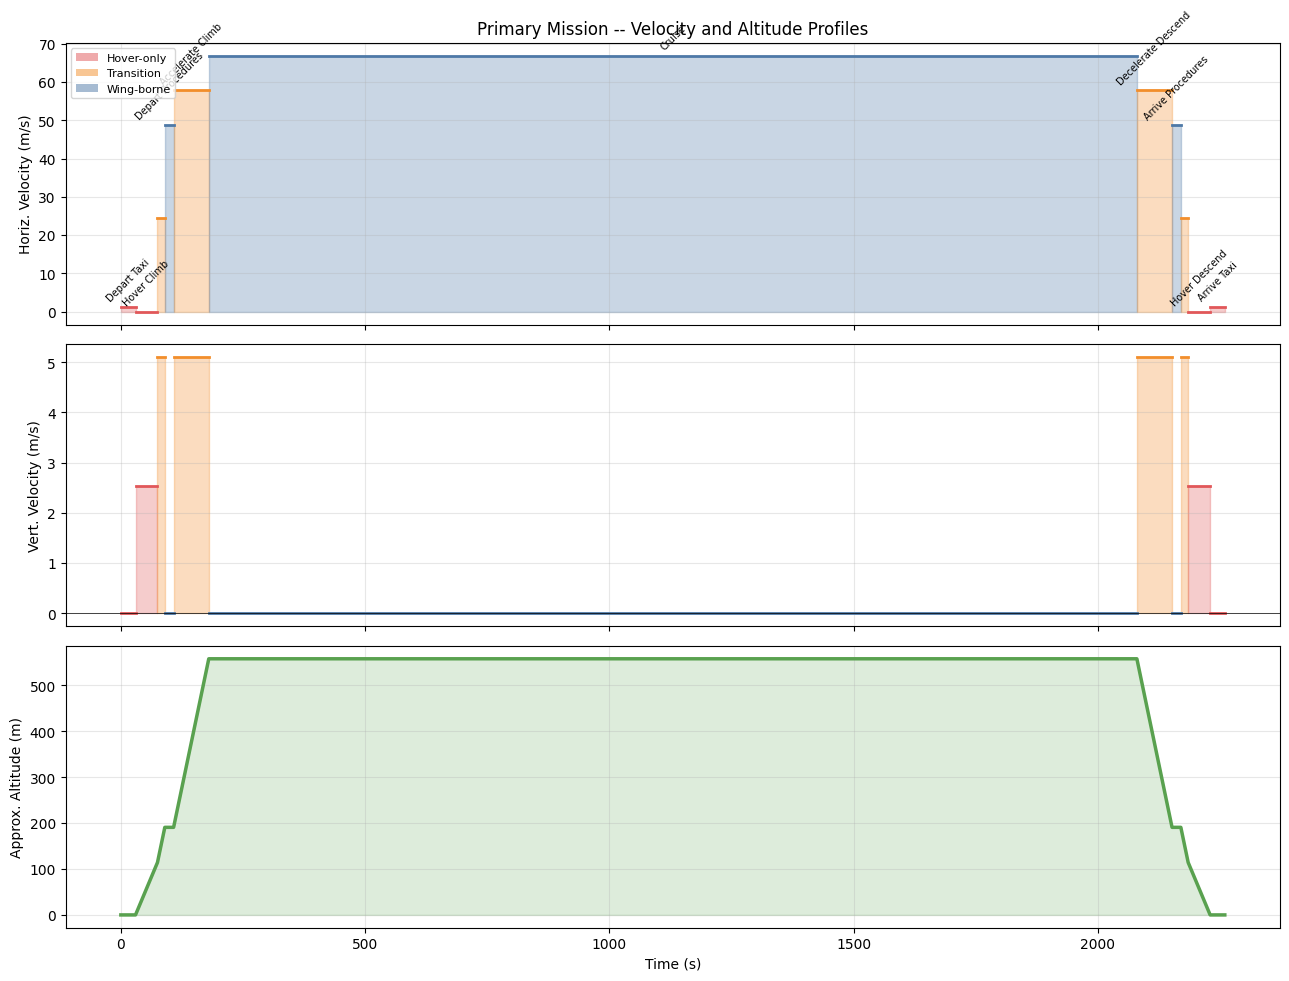

In [13]:
import matplotlib.pyplot as plt

# Build time series
t_starts = []
t_ends = []
vh_vals = []
vv_vals = []
seg_names = []
t = 0.0
for name, vh, vv, dt in primary_segments:
    t_starts.append(t)
    t_ends.append(t + dt)
    vh_vals.append(vh)
    vv_vals.append(vv)
    seg_names.append(name)
    t += dt

# Compute approximate altitude profile by integrating vertical velocity
altitudes = [0.0]  # start at ground
alt = 0.0
for i, (vv, dt_seg) in enumerate(zip(vv_vals, [dt for _, _, _, dt in primary_segments])):
    # Reverse vertical velocity after time ~2000
    seg_time = t_starts[i]
    if seg_time >= 2000:
        vv = -vv
    alt += vv * dt_seg
    # Prevent altitude from going below zero (ground level)
    alt = max(alt, 0.0)
    altitudes.append(alt)
alt_times = [t_starts[0]] + t_ends

# Segment colors by power category
seg_colors = []
for name in seg_names:
    if 'Taxi' in name or 'Hover' in name:
        seg_colors.append('#e15759')   # red = hover-only
    elif 'Transition' in name or 'Accel' in name or 'Decel' in name:
        seg_colors.append('#f28e2b')   # orange = transition
    else:
        seg_colors.append('#4e79a7')   # blue = wing-borne

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

# Panel 1: Horizontal velocity
for i in range(len(seg_names)):
    axes[0].fill_between([t_starts[i], t_ends[i]], [vh_vals[i], vh_vals[i]],
                          alpha=0.3, color=seg_colors[i])
    axes[0].plot([t_starts[i], t_ends[i]], [vh_vals[i], vh_vals[i]],
                  color=seg_colors[i], linewidth=2)
    mid = (t_starts[i] + t_ends[i]) / 2
    if (t_ends[i] - t_starts[i]) > 15:
        axes[0].text(mid, vh_vals[i] + 1.5, seg_names[i], ha='center', fontsize=7, rotation=45)
axes[0].set_ylabel('Horiz. Velocity (m/s)')
axes[0].set_title('Primary Mission -- Velocity and Altitude Profiles')
axes[0].grid(True, alpha=0.3)

# Panel 2: Vertical velocity
for i in range(len(seg_names)):
    axes[1].fill_between([t_starts[i], t_ends[i]], [vv_vals[i], vv_vals[i]],
                          alpha=0.3, color=seg_colors[i])
    axes[1].plot([t_starts[i], t_ends[i]], [vv_vals[i], vv_vals[i]],
                  color=seg_colors[i], linewidth=2)
axes[1].set_ylabel('Vert. Velocity (m/s)')
axes[1].axhline(y=0, color='black', linewidth=0.5)
axes[1].grid(True, alpha=0.3)

# Panel 3: Approximate altitude
axes[2].plot(alt_times, altitudes, color='#59a14f', linewidth=2.5)
axes[2].fill_between(alt_times, altitudes, alpha=0.2, color='#59a14f')
axes[2].set_ylabel('Approx. Altitude (m)')
axes[2].set_xlabel('Time (s)')
axes[2].grid(True, alpha=0.3)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e15759', alpha=0.5, label='Hover-only'),
                   Patch(facecolor='#f28e2b', alpha=0.5, label='Transition'),
                   Patch(facecolor='#4e79a7', alpha=0.5, label='Wing-borne')]
axes[0].legend(handles=legend_elements, loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

## Summary

The mission profile defines every phase of flight from taxi to landing:

- **11 primary segments** cover the full vertiport-to-vertiport flight
- **7 reserve segments** ensure the aircraft can divert after the primary mission
- Each segment specifies horizontal velocity, vertical velocity, and duration
- Segments are categorized by power model: **hover-only** (momentum theory), **wing-borne** (drag-based), or **transition** (combined)
- **Cruise dominates** the energy demand (longest duration) but **hover segments dominate** the power demand

The detailed equations for each segment's shaft power calculation are documented in `docs/theory/evtol-sizing.md`.

**Next:** [02 - Mission Timeline Visualization]